<a href="https://colab.research.google.com/github/Taniya-roy20/ML-PROJECT/blob/main/Multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)

Saving apple.csv to apple.csv
Uploaded file: apple.csv


Original Dataset Shape: (128, 12)

Processed Dataset:
   Year  Area_Harvested   Yield
0  1961         44500.0  4157.3
1  1962         38500.0  4155.8
2  1963         33700.0  4154.3
3  1964         26500.0  4150.9
4  1965         21700.0  4147.5

Number of Years: 64

Training Samples: 54
Testing Samples : 10


MULTIVARIATE LINEAR REGRESSION

Intercept:
-188941.2085

Coefficients:
Year : 98.420056
Area_Harvested : -0.006395

Model Equation:
Yield = -188941.2085 + (98.420056 × Year) + (-0.006395 × Area_Harvested)


-------------------------------------------------------
TRAINING METRICS
-------------------------------------------------------
MSE      : 624235.4723
RMSE     : 790.0857
MAE      : 582.6600
R² Score : 0.6235


-------------------------------------------------------
TESTING METRICS
-------------------------------------------------------
MSE      : 606414.7027
RMSE     : 778.7263
MAE      : 614.8514
R² Score : 0.2133


-------------------------------------------------------
AC

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


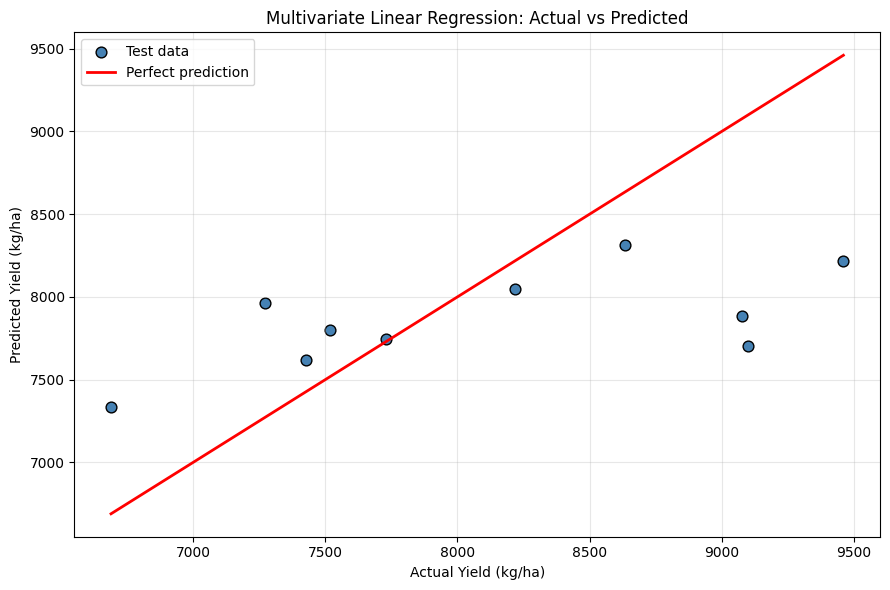

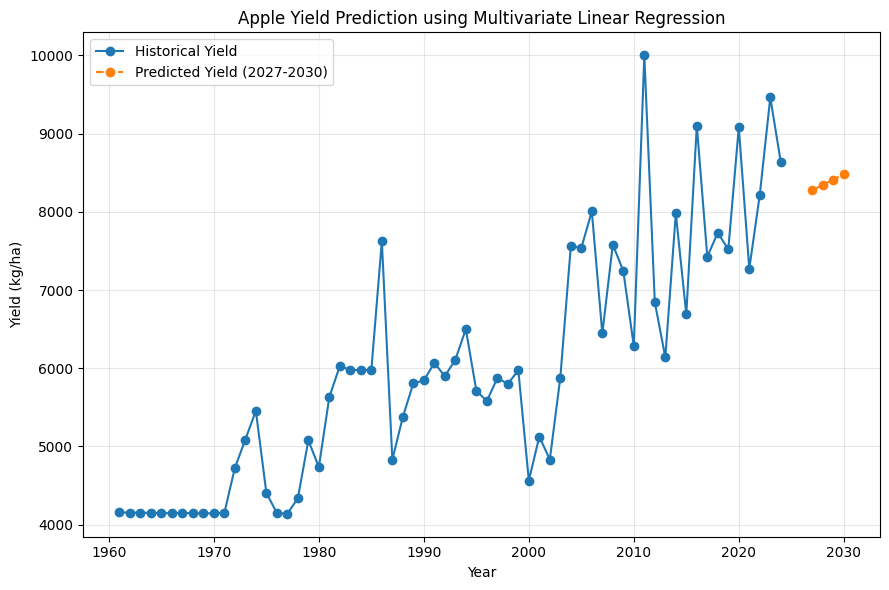


Graphs saved successfully!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# 1. LOAD DATA
# ============================================================

CSV_PATH = "apple.csv"

df = pd.read_csv(CSV_PATH)

print("Original Dataset Shape:", df.shape)


# ============================================================
# 2. SELECT REQUIRED COLUMNS
# ============================================================

data = df[["Element", "Year", "Value"]].copy()

data["Year"] = pd.to_numeric(
    data["Year"],
    errors="coerce"
)

data["Value"] = pd.to_numeric(
    data["Value"],
    errors="coerce"
)

data = data.dropna()


# ============================================================
# 3. SEPARATE AREA HARVESTED AND YIELD
# ============================================================

area_data = data[
    data["Element"] == "Area harvested"
][["Year", "Value"]].copy()

yield_data = data[
    data["Element"] == "Yield"
][["Year", "Value"]].copy()


# Rename columns

area_data.columns = [
    "Year",
    "Area_Harvested"
]

yield_data.columns = [
    "Year",
    "Yield"
]


# ============================================================
# 4. MERGE BOTH DATASETS BY YEAR
# ============================================================

data = pd.merge(
    area_data,
    yield_data,
    on="Year",
    how="inner"
)

data = data.sort_values("Year")

data = data.dropna()


print("\nProcessed Dataset:")
print(data.head())

print("\nNumber of Years:", len(data))


# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

# Independent variables
X = data[
    [
        "Year",
        "Area_Harvested"
    ]
]

# Dependent variable
y = data["Yield"]


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

# Since this is time-series data,
# use earlier years for training
# and later years for testing.

split_year = 2014

train_data = data[
    data["Year"] <= split_year
]

test_data = data[
    data["Year"] > split_year
]


X_train = train_data[
    [
        "Year",
        "Area_Harvested"
    ]
]

y_train = train_data["Yield"]


X_test = test_data[
    [
        "Year",
        "Area_Harvested"
    ]
]

y_test = test_data["Yield"]


print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# 7. TRAIN MULTIVARIATE LINEAR REGRESSION
# ============================================================

model = LinearRegression()

model.fit(
    X_train,
    y_train
)


# ============================================================
# 8. PREDICTIONS ON TRAINING DATA
# ============================================================

y_train_pred = model.predict(
    X_train
)


# ============================================================
# 9. PREDICTIONS ON TEST DATA
# ============================================================

y_test_pred = model.predict(
    X_test
)


# ============================================================
# 10. EVALUATION METRICS
# ============================================================

# ---------- Training Metrics ----------

train_mse = mean_squared_error(
    y_train,
    y_train_pred
)

train_rmse = np.sqrt(
    train_mse
)

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)


# ---------- Testing Metrics ----------

test_mse = mean_squared_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(
    test_mse
)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)


# ============================================================
# 11. DISPLAY MODEL EQUATION
# ============================================================

print("\n")
print("=" * 55)
print("MULTIVARIATE LINEAR REGRESSION")
print("=" * 55)

print("\nIntercept:")
print(f"{model.intercept_:.4f}")


print("\nCoefficients:")

for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(
        f"{feature} : {coefficient:.6f}"
    )


print("\nModel Equation:")

print(
    f"Yield = {model.intercept_:.4f} "
    f"+ ({model.coef_[0]:.6f} × Year) "
    f"+ ({model.coef_[1]:.6f} × Area_Harvested)"
)


# ============================================================
# 12. TRAINING METRICS
# ============================================================

print("\n")
print("-" * 55)
print("TRAINING METRICS")
print("-" * 55)

print(f"MSE      : {train_mse:.4f}")
print(f"RMSE     : {train_rmse:.4f}")
print(f"MAE      : {train_mae:.4f}")
print(f"R² Score : {train_r2:.4f}")


# ============================================================
# 13. TESTING METRICS
# ============================================================

print("\n")
print("-" * 55)
print("TESTING METRICS")
print("-" * 55)

print(f"MSE      : {test_mse:.4f}")
print(f"RMSE     : {test_rmse:.4f}")
print(f"MAE      : {test_mae:.4f}")
print(f"R² Score : {test_r2:.4f}")


# ============================================================
# 14. ACTUAL VS PREDICTED TEST VALUES
# ============================================================

results = pd.DataFrame({
    "Year": test_data["Year"].values,
    "Actual Yield": y_test.values,
    "Predicted Yield": y_test_pred
})

print("\n")
print("-" * 55)
print("ACTUAL VS PREDICTED YIELD")
print("-" * 55)

print(results.to_string(index=False))


# ============================================================
# 15. PREDICT FUTURE AREA HARVESTED
# ============================================================

# We need Area_Harvested for 2027-2030
# because it is one of our independent variables.

area_model = LinearRegression()

area_X = data[
    ["Year"]
]

area_y = data[
    "Area_Harvested"
]

area_model.fit(
    area_X,
    area_y
)


# Future years

future_years = np.arange(
    2027,
    2031
)


# Predict future harvested area

future_area = area_model.predict(
    future_years.reshape(-1, 1)
)


# Prevent negative values
future_area = np.maximum(
    future_area,
    0
)


# ============================================================
# 16. FUTURE YIELD PREDICTION
# ============================================================

future_data = pd.DataFrame({
    "Year": future_years,
    "Area_Harvested": future_area
})


future_yield = model.predict(
    future_data[
        [
            "Year",
            "Area_Harvested"
        ]
    ]
)


# ============================================================
# 17. DISPLAY FUTURE PREDICTIONS
# ============================================================

future_results = pd.DataFrame({
    "Year": future_years,
    "Predicted Area Harvested": future_area,
    "Predicted Yield": future_yield
})


print("\n")
print("=" * 55)
print("FUTURE APPLE YIELD PREDICTIONS")
print("=" * 55)

print(
    future_results.to_string(
        index=False
    )
)


# ============================================================
# 18. ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    y_test_pred,
    color="steelblue",
    edgecolor="black",
    s=60,
    label="Test data"
)


# Perfect prediction line

minimum = min(
    y_test.min(),
    y_test_pred.min()
)

maximum = max(
    y_test.max(),
    y_test_pred.max()
)


plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linewidth=2,
    label="Perfect prediction"
)


plt.xlabel(
    "Actual Yield (kg/ha)"
)

plt.ylabel(
    "Predicted Yield (kg/ha)"
)

plt.title(
    "Multivariate Linear Regression: Actual vs Predicted"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "multivariate_actual_vs_predicted.png",
    dpi=150
)

plt.show()


# ============================================================
# 19. FUTURE YIELD PREDICTION GRAPH
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    data["Year"],
    data["Yield"],
    marker="o",
    label="Historical Yield"
)


plt.plot(
    future_years,
    future_yield,
    marker="o",
    linestyle="--",
    label="Predicted Yield (2027-2030)"
)


plt.xlabel(
    "Year"
)

plt.ylabel(
    "Yield (kg/ha)"
)

plt.title(
    "Apple Yield Prediction using Multivariate Linear Regression"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "multivariate_future_prediction.png",
    dpi=150
)

plt.show()


print("\nGraphs saved successfully!")